# Exploratory data analysis

One year of weekly payments per farmer. Goal here is just to understand the data before building anything: how much farmers get paid, how consistent it is, how often they skip weeks, and whether there's any seasonal structure. The seasonality turns out to matter a lot.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from src.data import load_payments
from src.preprocessing import preprocess
from src.utils import WEEK_COLUMNS
from src import visualization as viz

raw, report = load_payments(return_report=True)
print(report.summary())
df = preprocess(raw)   # missing weeks -> 0
df.head()

1275 farmers x 52 weeks | missing cells: 11647 (17.6%) | duplicate ids: 0


,week1,week2,week3,week4,week5,week6,week7,week8,week9,week10,...,week43,week44,week45,week46,week47,week48,week49,week50,week51,week52
farmer_no,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2918.0,1882.0,1939.0,1115.0
2,6487.0,10898.0,5133.0,3138.0,3056.0,5293.0,3170.0,2751.0,0.0,3333.0,...,900.0,0.0,1931.0,122.0,0.0,2704.0,7147.0,5125.0,2589.0,917.0
3,1289.0,1392.0,1789.0,1319.0,662.0,2290.0,1994.0,2527.0,1172.0,3059.0,...,2104.0,2306.0,1206.0,1417.0,1310.0,2153.0,1771.0,3527.0,3665.0,3110.0
4,3844.0,4256.0,3716.0,4511.0,5209.0,7299.0,9899.0,7440.0,1915.0,18215.0,...,23350.0,26493.0,1217.0,2791.0,0.0,5203.0,7938.0,1909.0,850.0,546.0
5,3428.0,2346.0,2419.0,2110.0,1569.0,2110.0,1951.0,936.0,169.0,235.0,...,548.0,1216.0,657.0,225.0,357.0,0.0,0.0,181.0,189.0,76.0


## Size and missingness
A dash in the raw file means a skipped week. We read those as zero, since for a milk supplier a skipped week is a week with no delivery.

In [3]:
M = df[WEEK_COLUMNS].to_numpy()
print(f'farmers: {len(df)}')
print(f'zero-payment weeks: {(M==0).mean():.1%}')
print(f'mean weekly payment: {M[M>0].mean():,.0f}')
print(f'median weekly payment: {np.median(M[M>0]):,.0f}')

farmers: 1275
zero-payment weeks: 17.6%
mean weekly payment: 33,466
median weekly payment: 12,612


## Distribution of weekly and yearly payments

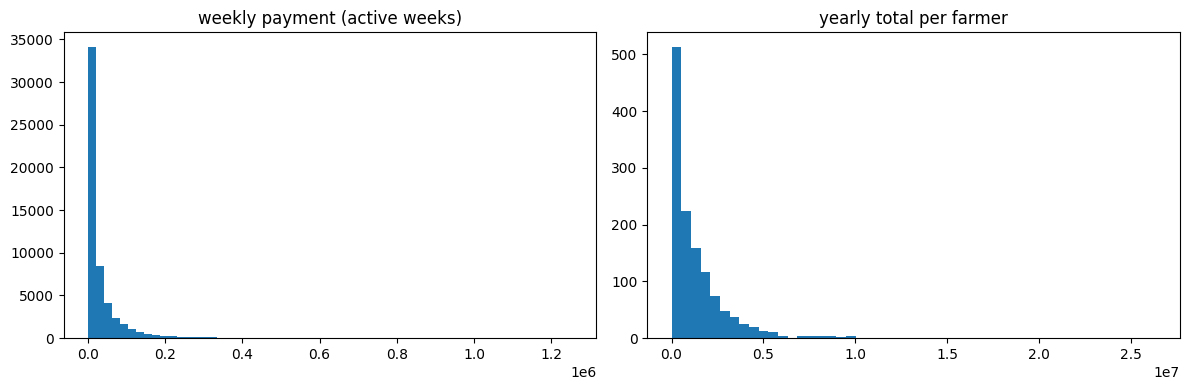

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
viz.plot_distribution(M[M>0], bins=60, title='weekly payment (active weeks)', ax=ax[0])
viz.plot_distribution(M.sum(axis=1), bins=50, title='yearly total per farmer', ax=ax[1])
plt.tight_layout()

Both are heavily right-skewed: most farmers are small, a few are large. That skew is why the risk score normalizes against population percentiles rather than raw values.

## How consistent are farmers?
Coefficient of variation (std / mean) per farmer. High CV means lumpy, unpredictable payments.

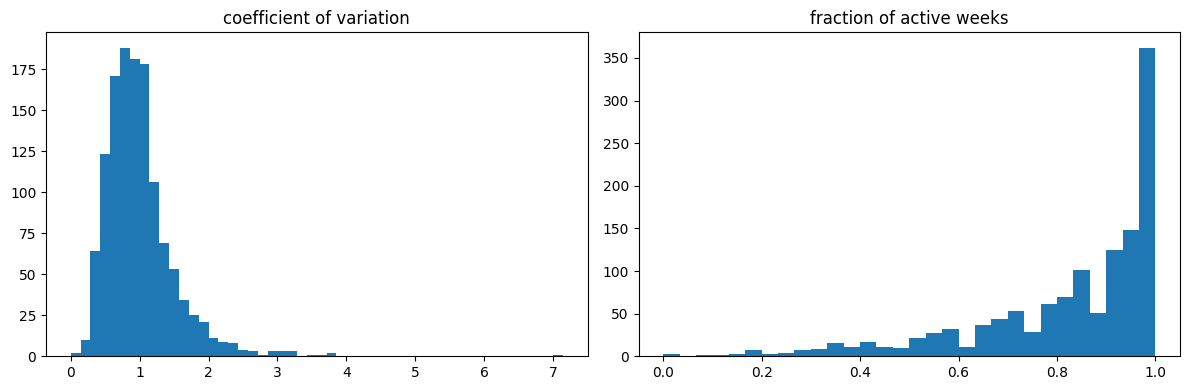

In [5]:
wk_mean = M.mean(axis=1)
wk_std = M.std(axis=1)
cv = np.divide(wk_std, wk_mean, out=np.zeros_like(wk_mean), where=wk_mean>0)
active_pct = (M>0).mean(axis=1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
viz.plot_distribution(cv, bins=50, title='coefficient of variation', ax=ax[0])
viz.plot_distribution(active_pct, bins=30, title='fraction of active weeks', ax=ax[1])
plt.tight_layout()

## A few example farmers

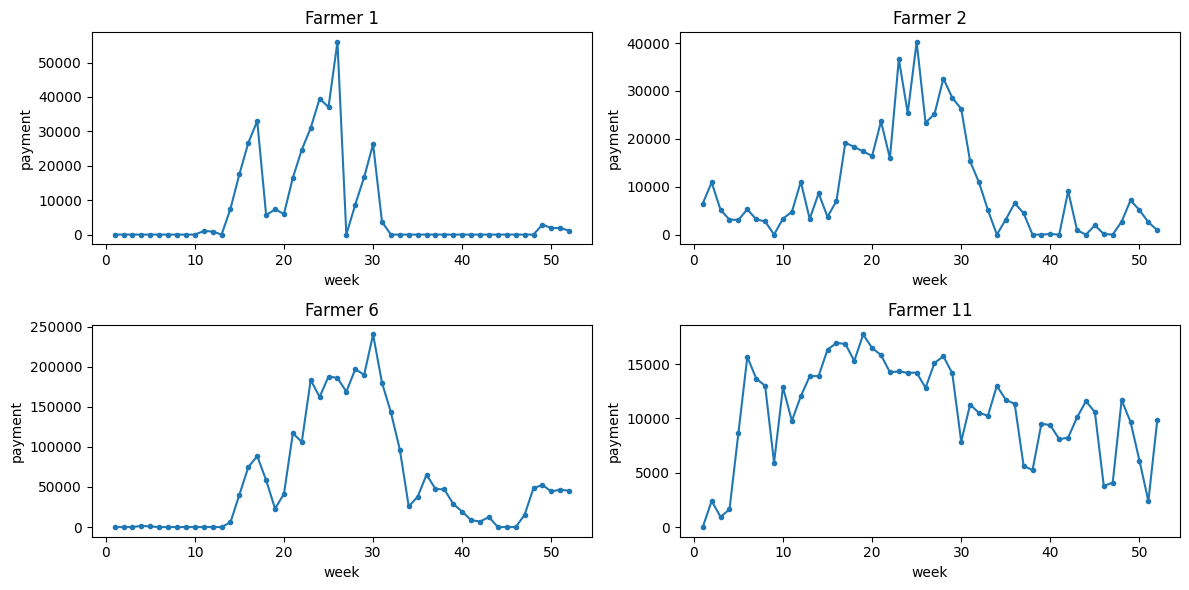

In [6]:
ids = df.index[[0, 1, 5, 10]]
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for fid, ax in zip(ids, axes.ravel()):
    viz.plot_payment_history(df, fid, ax=ax)
plt.tight_layout()

## Seasonality (the important bit)
Average payment across all farmers, week by week. This is the single most important thing in the dataset for lending.

wk1-39 mean: 32,747 | wk40-52 mean: 12,104


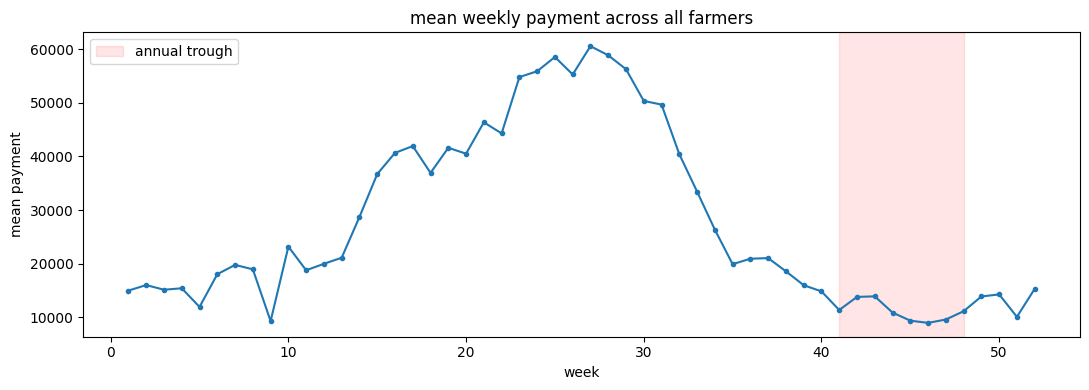

In [7]:
wk = M.mean(axis=0)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(range(1, 53), wk, marker='o', ms=3)
ax.axvspan(41, 48, color='red', alpha=0.1, label='annual trough')
ax.set_xlabel('week'); ax.set_ylabel('mean payment'); ax.set_title('mean weekly payment across all farmers')
ax.legend(); plt.tight_layout()
print('wk1-39 mean:', f'{M[:,:39].mean():,.0f}', '| wk40-52 mean:', f'{M[:,39:].mean():,.0f}')

Payments ramp up to a peak around weeks 21-28, then fall hard to an annual trough around weeks 41-48 (roughly a third of the peak). A 13-week loan can land entirely in that trough, so sizing a loan off the yearly average would badly over-lend. The whole sizing approach later is built around this.

## Week-to-week correlation

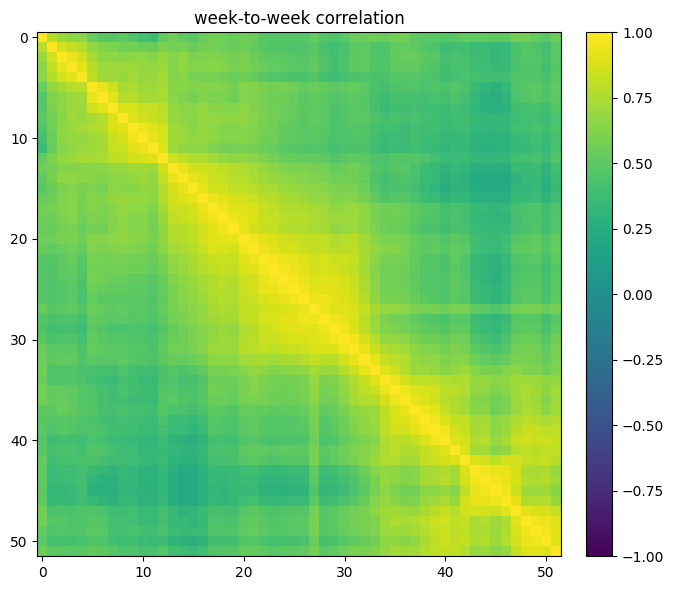

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
viz.plot_week_correlation(df, ax=ax)
plt.tight_layout()

Neighbouring weeks are positively correlated (payments move in seasonal blocks), which is why the simulation later resamples in blocks rather than treating weeks as independent.